In [ ]:
!pip install transformers pandas scikit-learn

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

train_raw = pd.read_csv(
    '/content/drive/MyDrive/NLP Dataset files/train.csv',
    engine='python',
    on_bad_lines='skip'
)

test_raw = pd.read_csv(
    '/content/drive/MyDrive/NLP Dataset files/test.csv',
    engine='python',
    on_bad_lines='skip'
)

print("Train:", train_raw.shape)
print("Test:", test_raw.shape)


Train: (3600000, 2)
Test: (400000, 2)


In [ ]:
import pandas as pd

train_raw = pd.read_csv(
    'train.csv',
    engine='python',
    on_bad_lines='skip'
)

print("Train Shape:", train_raw.shape)
print("Train Columns:", train_raw.columns.tolist())
print(train_raw.head(3))
print("\nTrain Labels:", train_raw['Label'].unique())
print(train_raw['Label'].value_counts())

Train Shape: (133476, 2)
Train Columns: ['Review', 'Label']
                                              Review  Label
0  Stuning even for the non-gamer: This sound tra...      2
1  The best soundtrack ever to anything.: I'm rea...      2
2  Amazing!: This soundtrack is my favorite music...      2

Train Labels: [2 1]
Label
2    67751
1    65725
Name: count, dtype: int64


In [ ]:
test_raw = pd.read_csv(
    'test.csv',
    engine='python',
    on_bad_lines='skip'
)

print("Test Shape:", test_raw.shape)
print("Test Labels:", test_raw['Label'].unique())
print(test_raw['Label'].value_counts())

Test Shape: (113149, 2)
Test Labels: [2 1]
Label
2    57289
1    55860
Name: count, dtype: int64


In [ ]:
df = train_raw.sample(n=10000, random_state=42)

df['Label'] = df['Label'].map({1: 0, 2: 1})

print("Shape after sampling:", df.shape)
print("Labels after fix:", df['Label'].unique())
print(df['Label'].value_counts())

Shape after sampling: (10000, 2)
Labels after fix: [1 0]
Label
1    5113
0    4887
Name: count, dtype: int64


In [ ]:
print(df.shape)

(10000, 2)


In [ ]:
from sklearn.model_selection import train_test_split

train_val, test_df = train_test_split(df,test_size=0.15,random_state=42)
train_df, val_df = train_test_split(train_val,test_size=0.176,random_state=42)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 7004
Validation: 1496
Test: 1500


In [ ]:
train_df = train_df.rename(columns={'Review': 'text', 'Label': 'label'})
val_df   = val_df.rename(columns={'Review': 'text', 'Label': 'label'})
test_df  = test_df.rename(columns={'Review': 'text', 'Label': 'label'})

print("Columns:", train_df.columns.tolist())
print("Sample:")
print(train_df.head(2))

Columns: ['text', 'label']
Sample:
                                                    text  label
17268  ok: It is a decent little kit, but not worth t...      0
80884  Fans of Underground music should love!: Catchy...      1


In [ ]:
print(df['Label'].unique())

[1 0]


In [ ]:
!pip install transformers

In [ ]:
from transformers import DistilBertTokenizer

tokenizer = DistilBertTokenizer.from_pretrained(
    'distilbert-base-uncased'
)

sample = train_df['text'].head(5).tolist()
encodings = tokenizer(
    sample,
    truncation=True,
    padding=True,
    max_length=128
)

print("Tokenization keys:", encodings.keys())


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenization keys: KeysView({'input_ids': [[101, 7929, 1024, 2009, 2003, 1037, 11519, 2210, 8934, 1010, 2021, 2025, 4276, 1996, 1002, 2017, 3477, 2005, 2009, 1012, 2210, 9364, 1010, 2071, 2031, 2109, 2062, 1999, 1996, 8934, 1012, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [101, 4599, 1997, 5230, 2189, 2323, 2293, 999, 1024, 4608, 2100, 2004, 3109, 1010, 2023, 2201, 2003, 2019, 7107, 4438, 1999, 1996, 12818, 1997, 5230, 2189, 1010, 2066, 1996, 11865, 5620, 1010, 2030, 1996, 18781, 12735, 1012, 1996, 2316, 2171, 1011, 9010, 1037, 2843, 1997, 7490, 2576, 4481, 1006, 1999, 1000, 2980, 8476, 1000, 1007, 1010, 2021, 1996, 4581, 4995, 1005, 1056, 3722, 20228, 10450, 8525, 6155, 2030, 14558, 2015, 1012, 2027, 1005, 2128, 13805, 1010, 27243, 1010, 

In [ ]:
import torch
from transformers import (DistilBertTokenizer,
                          DistilBertForSequenceClassification)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=2  )

model = model.to(device)
print("Model loaded")
print("Model Architecture:")
print(model)

Device: cuda


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded
Model Architecture:
DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout

In [ ]:
from torch.utils.data import Dataset
class ReviewDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len=128):
         self.texts  = dataframe['text'].tolist()
         self.labels = dataframe['label'].tolist()
         self.tokenizer = tokenizer
         self.max_len = max_len
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, index):
            text = str(self.texts[index])
            label = self.labels[index]
            encoding = self.tokenizer(text,truncation=True,padding='max_length',max_length=self.max_len,return_tensors='pt')

            return {
            'input_ids': encoding['input_ids'].squeeze(),'attention_mask': encoding['attention_mask'].squeeze(),'labels': torch.tensor(label, dtype=torch.long)

        }
train_dataset = ReviewDataset(train_df, tokenizer)
val_dataset   = ReviewDataset(val_df,   tokenizer)
test_dataset  = ReviewDataset(test_df,  tokenizer)

print(f"Train Dataset: {len(train_dataset)} samples ✅")
print(f"Val Dataset:   {len(val_dataset)} samples ✅")
print(f"Test Dataset:  {len(test_dataset)} samples ✅")


Train Dataset: 7004 samples ✅
Val Dataset:   1496 samples ✅
Test Dataset:  1500 samples ✅


In [ ]:
from transformers import TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='weighted')
    return {'accuracy': acc, 'f1': f1}

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    warmup_steps=100,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    logging_steps=50,
    logging_dir='./logs',
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

print("Trainer ready")
print("\nHyperparameters Summary:")
print(f"Epochs:         3")
print(f"Batch Size:     16")
print(f"Learning Rate:  2e-5")
print(f"Train Samples:  {len(train_dataset)}")
print(f"Val Samples:    {len(val_dataset)}")

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Trainer ready

Hyperparameters Summary:
Epochs:         3
Batch Size:     16
Learning Rate:  2e-5
Train Samples:  7004
Val Samples:    1496


In [ ]:


print("Training started... Please wait")
print("Do not close or refresh Colab!\n")

trainer.train()

print("\nTraining Complete")

Training started... Please wait
Do not close or refresh Colab!



Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.205363,0.187535,0.931150,0.931140
2,0.155166,0.179104,0.939840,0.939845
3,0.073379,0.227514,0.939171,0.939182


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Training Complete


In [ ]:
print("Generating predictions on test set...")

predictions = trainer.predict(test_dataset)

preds = predictions.predictions.argmax(-1)


true_labels = predictions.label_ids

print(f"Total predictions: {len(preds)}")
print(f"Sample predictions: {preds[:10]}")
print(f"Sample true labels: {true_labels[:10]}")

Generating predictions on test set...


Total predictions: 1500
Sample predictions: [1 1 0 1 1 1 0 1 0 0]
Sample true labels: [1 1 0 1 1 1 0 1 0 0]


In [ ]:
from sklearn.metrics import (accuracy_score,
                             precision_score,
                             recall_score,
                             f1_score,
                             classification_report)

accuracy  = accuracy_score(true_labels, preds)
precision = precision_score(true_labels, preds, average='weighted')
recall    = recall_score(true_labels, preds, average='weighted')
f1        = f1_score(true_labels, preds, average='weighted')

print("=" * 40)
print("       EVALUATION RESULTS")
print("=" * 40)
print(f"Accuracy  : {accuracy*100:.2f}%")
print(f"Precision : {precision*100:.2f}%")
print(f"Recall    : {recall*100:.2f}%")
print(f"F1 Score  : {f1*100:.2f}%")
print("=" * 40)

print("\nDetailed Classification Report:")
print(classification_report(
    true_labels,
    preds,
    target_names=['Negative', 'Positive']
))

       EVALUATION RESULTS
Accuracy  : 94.07%
Precision : 94.19%
Recall    : 94.07%
F1 Score  : 94.07%

Detailed Classification Report:
              precision    recall  f1-score   support

    Negative       0.92      0.96      0.94       717
    Positive       0.97      0.92      0.94       783

    accuracy                           0.94      1500
   macro avg       0.94      0.94      0.94      1500
weighted avg       0.94      0.94      0.94      1500



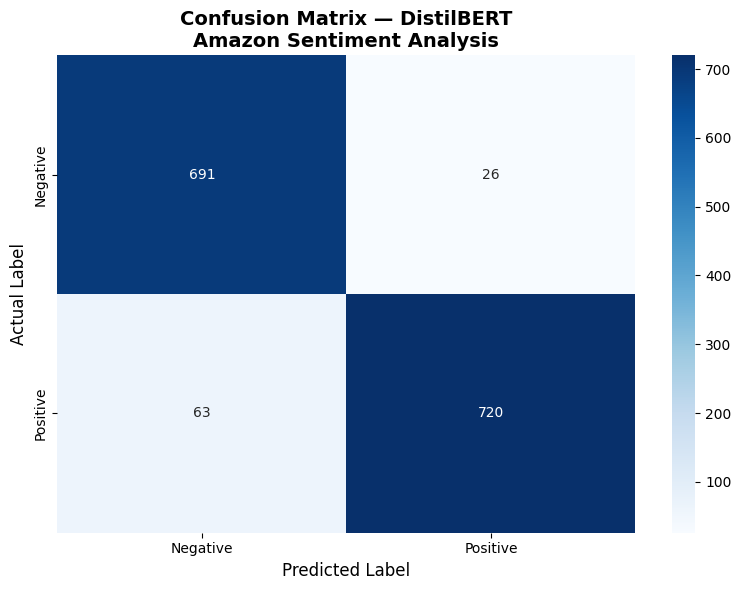

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(true_labels, preds)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)

plt.title('Confusion Matrix — DistilBERT\nAmazon Sentiment Analysis',
          fontsize=14, fontweight='bold')
plt.ylabel('Actual Label',    fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()


In [22]:
print("=" * 60)
print("      EXAMPLE PREDICTIONS")
print("=" * 60)

label_names = {0: 'Negative', 1: 'Positive'}

sample_indices = range(10)

for i in sample_indices:
    review      = test_df['text'].iloc[i]
    true_label  = test_df['label'].iloc[i]
    pred_label  = preds[i]

    short_review = review[:80] + "..." if len(review) > 80 else review

    print(f"\nReview    : {short_review}")
    print(f"Actual    : {label_names[true_label]}")
    print(f"Predicted : {label_names[pred_label]}")
    print(f"Correct?  : {'Yes' if true_label == pred_label
                         else 'No'}")
    print("-" * 60)

      EXAMPLE PREDICTIONS

Review    : A masterpiece, pure and simple. Buy it.: Gervais and Merchant prove that their c...
Actual    : Positive
Predicted : Positive
Correct?  : Yes
------------------------------------------------------------

Review    : A heartfelt, funny and touching rendition of fatherhood.: This book is one of th...
Actual    : Positive
Predicted : Positive
Correct?  : Yes
------------------------------------------------------------

Review    : As bad as Xenocide: I loved Game, Shadow & Speaker. However, I will never unders...
Actual    : Negative
Predicted : Negative
Correct?  : Yes
------------------------------------------------------------

Review    : This is what Talking Heads is all About at thier Commercial Height: I have alway...
Actual    : Positive
Predicted : Positive
Correct?  : Yes
------------------------------------------------------------

Review    : GREAT!: Here's the original Godzilla in a nutshell:Good acting(escpecially by Ra...
Actual    : P

In [23]:
print("=" * 50)
print("        FINAL MODEL SUMMARY")
print("=" * 50)
print(f"Model      : DistilBERT (distilbert-base-uncased)")
print(f"Task       : Binary Sentiment Classification")
print(f"Classes    : Negative (0) vs Positive (1)")
print(f"Dataset    : Amazon Product Reviews")
print(f"Train Size : {len(train_df)}")
print(f"Val Size   : {len(val_df)}")
print(f"Test Size  : {len(test_df)}")
print(f"Epochs     : 3")
print(f"Batch Size : 16")
print(f"LR         : 2e-5")
print("-" * 50)
print(f"Accuracy   : {accuracy*100:.2f}%")
print(f"Precision  : {precision*100:.2f}%")
print(f"Recall     : {recall*100:.2f}%")
print(f"F1 Score   : {f1*100:.2f}%")
print("=" * 50)

        FINAL MODEL SUMMARY
Model      : DistilBERT (distilbert-base-uncased)
Task       : Binary Sentiment Classification
Classes    : Negative (0) vs Positive (1)
Dataset    : Amazon Product Reviews
Train Size : 7004
Val Size   : 1496
Test Size  : 1500
Epochs     : 3
Batch Size : 16
LR         : 2e-5
--------------------------------------------------
Accuracy   : 94.07%
Precision  : 94.19%
Recall     : 94.07%
F1 Score   : 94.07%


In [24]:
!git config --global user.f2023065346@umt.edu.pk
!git config --global user.Eisha373

In [25]:
!git clone https://github.com/Eisha373/Amazon-sentiment-analysis.git

Cloning into 'Amazon-sentiment-analysis'...
remote: Enumerating objects: 12, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 12 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (12/12), 52.27 KiB | 6.53 MiB/s, done.
Resolving deltas: 100% (1/1), done.


In [26]:
!pip install gradio -q
print("Gradio installed")

Gradio installed


In [27]:
import gradio as gr
import torch
from transformers import DistilBertTokenizer

tokenizer = DistilBertTokenizer.from_pretrained(
    'distilbert-base-uncased'
)

def predict_sentiment(review_text):

    if not review_text.strip():
        return "Please enter a review!"

    inputs = tokenizer(
        review_text,
        truncation=True,
        padding=True,
        max_length=128,
        return_tensors='pt'
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    probs = torch.softmax(outputs.logits, dim=1)
    pred  = torch.argmax(probs, dim=1).item()

    neg_prob = probs[0][0].item() * 100
    pos_prob = probs[0][1].item() * 100

    if pred == 1:
        return f"""POSITIVE REVIEW

Confidence:
- Positive : {pos_prob:.1f}%
- Negative : {neg_prob:.1f}%

The customer is satisfied with the product."""
    else:
        return f""" NEGATIVE REVIEW

Confidence:
- Positive : {pos_prob:.1f}%
- Negative : {neg_prob:.1f}%

The customer is NOT satisfied with the product."""

print("Function ready")

Function ready


In [29]:
app = gr.Interface(
    fn=predict_sentiment,

    inputs=gr.Textbox(
        lines=5,
        placeholder="Type your Amazon review here...\n\nExample: This product is amazing, highly recommended!",
        label=" Enter Amazon Review"
    ),

    outputs=gr.Textbox(
        label=" Sentiment Prediction",
        lines=8
    ),

    title=" Amazon Review Sentiment Analyzer",

    description="""
    This app uses DistilBERT (Fine-tuned on Amazon Reviews)
    to predict whether a review is Positive or Negative.

    Model Accuracy: 94.07%
    """,

    examples=[
        ["This product is absolutely amazing! Best purchase ever! Highly recommended!"],
        ["Terrible quality, broke after one day. Complete waste of money. Very disappointed."],
        ["It works okay but nothing special. Average product for the price."],
        ["Fast delivery and great packaging. Product works exactly as described!"],
        ["Do not buy this! Stopped working after a week. Very poor quality."]
    ],

    theme=gr.themes.Soft()
)
app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://350ec188e4b7ff2db6.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [30]:

model.save_pretrained("./saved_model")
tokenizer.save_pretrained("./saved_model")

import os
print(os.listdir("./saved_model"))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

['tokenizer.json', 'tokenizer_config.json', 'model.safetensors', 'config.json']


In [32]:
!pip install huggingface_hub -q

from huggingface_hub import HfApi, login

login()

api = HfApi()
api.create_repo(
    repo_id="EishaSohail/amazon-sentiment-model",
    private=False
)

from transformers import DistilBertForSequenceClassification
model.push_to_hub("EishaSohail/amazon-sentiment-model")
tokenizer.push_to_hub("EishaSohail/amazon-sentiment-model")

print("Model uploaded")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...60e62k_/model.safetensors:   0%|          |  575kB /  268MB            

README.md:   0%|          | 0.00/5.17k [00:00<?, ?B/s]

Model uploaded


In [1]:
!git clone https://github.com/Eisha373/nlp-sentiment-analysis.git

import shutil
import os

print(os.listdir('/content/'))

Cloning into 'nlp-sentiment-analysis'...
fatal: could not read Username for 'https://github.com': No such device or address
['.config', 'sample_data']
